# Experimentos da FixMatch variando o $\tau$ e $\lambda_u$


# Implementação e Avaliação do FixMatch com CIFAR-10

### Objetivo
Neste assignment, vocês implementarão o método FixMatch, uma técnica de aprendizado semi-supervisionado que combina aprendizado supervisionado e não supervisionado. O objetivo é aplicar o FixMatch ao dataset CIFAR-10 para treinar uma rede neural e avaliar os resultados obtidos com diferentes proporções de dados rotulados.

### 1. Introdução ao FixMatch
FixMatch é uma técnica que combina pseudo-rotulagem e consistência de dados aumentados. Em resumo, o método:
- **Gera pseudo-rótulos** para dados não rotulados, utilizando uma predição confiável de dados fracamente aumentados.
- **Aplica uma consistência de pseudo-rótulos**, onde a rede é treinada para produzir as mesmas previsões em versões fortemente aumentadas das mesmas imagens.

Para mais informações sobre a arquitetura e a metodologia do FixMatch, vocês podem consultar o [paper original](https://arxiv.org/abs/2001.07685) e/ou ver os slides disponibilizados.

### 2. Estrutura da Implementação

1. **Dataset e Preparação dos Dados**  
   - Use o CIFAR-10 como dataset.
   - Prepare duas versões dos dados:
     - **Dados rotulados:** Utilizem um subconjunto rotulado do CIFAR-10 com diferentes quantidades de rótulos por classe para experimentação.
     - **Dados não rotulados:** O restante do CIFAR-10 deve ser usado como dados não rotulados.

2. **Modelo Base**  
   - Utilize um modelo de CNN simples ou uma arquitetura pré-definida (sugestão: ResNet-18) para a implementação.

3. **Implementação do FixMatch**
   - **Pseudo-rotulagem:** Implemente a geração de rótulos para os dados não rotulados usando predições de confiança de uma versão levemente aumentada da imagem.
   - **Consistência de Augmentation:** Aplique uma versão fortemente aumentada da imagem e treine a rede para manter consistência nos pseudo-rótulos.
   - **Função de Perda**:
     - O FixMatch utiliza uma função de perda híbrida, combinando a perda supervisionada e a não supervisionada:
       - **Perda Supervisionada:** Aplique a entropia cruzada entre os rótulos reais e as predições do modelo para os dados rotulados.
       - **Perda Não Supervisionada (Consistência de Pseudo-rótulos):** Para os dados não rotulados, aplique uma entropia cruzada entre os pseudo-rótulos e as previsões das imagens aumentadas, incluindo apenas as amostras com confiança acima de um limite predefinido (threshold).
       - A função de perda final é a soma ponderada das perdas supervisionada e não supervisionada.

   - **Detalhes Importantes nas Seções 2.3 e 2.4 do paper**;

4. **Treinamento e Otimização**

### 3. Experimentos e Análise

Para avaliar o desempenho do FixMatch, vocês devem realizar experimentos com diferentes quantidades de dados rotulados. Especificamente, testem com:

1. **1 rótulo por classe** (total de 10 rótulos): Este experimento extremo explora o desempenho do FixMatch com uma quantidade mínima de dados rotulados. Observem a eficácia da técnica de pseudo-rotulagem nesse cenário.

2. **4 rótulos por classe** (total de 40 rótulos): Com um conjunto pequeno, analisem o desempenho da rede com algumas amostras rotuladas e o impacto dos pseudo-rótulos.

3. **25 rótulos por classe** (total de 250 rótulos): Esse experimento permitirá uma análise mais profunda da eficácia do FixMatch em cenários com uma quantidade moderada de rótulos.

4. **400 rótulos por classe** (total de 4.000 rótulos): Avaliem o desempenho do modelo com um conjunto mais substancial de dados rotulados, investigando o impacto da quantidade crescente de rótulos.

**Proponha pelo menos mais algum teste, fundamente sua escolha e discuta os resultados.**

Para cada experimento:
   - Treine o modelo e avalie a acurácia nos dados de teste.
   - Documente os resultados e compare a eficácia do FixMatch com a quantidade de dados rotulados disponíveis.
   - Analise o impacto dos pseudo-rótulos na qualidade do modelo, principalmente nos cenários com poucos rótulos (1, 4 e 25 rótulos por classe).

### 4. Apresentação
No final, vocês devem preparar e apresentar:

1. Slides de apresentação ou relatório:
- Explicação da implementação de cada parte do FixMatch. (simples e rápida)
- Resultados e gráficos das avaliações para os quatro cenários de rótulos por classe. (Importante)
- Análise sobre o impacto da quantidade de dados rotulados, a função de perda híbrida, e o efeito dos thresholds e data augmentation. (Importante)

2. Apresentação de 10-15 minutos
- Grave uma apresentação do seu slide/relatório cobrindo todos os pontos pedidos.

*Note que a apresentação e o conteúdo dos slides deve cobrir todos os requisitos solicitados, pois sua avaliação vai depender 90% da apresentação.



# Introdução
Implementação FixMatch - CIFAR-10

## 1. Imports e Configurações

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
from PIL import Image, ImageOps, ImageEnhance
import copy

# Configurações
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

# Seed para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Usando dispositivo: cuda


## Data Augmentations ( Seção 2.3 )

### Weak Augmentation
_In all of our experiments,
weak augmentation is a standard ﬂip-and-shift augmentation strategy. Speciﬁcally, we randomly
ﬂip images horizontally with a probability of 50% on all datasets except SVHN and we randomly
translate images by up to 12.5% vertically and horizontally._

In [3]:
class WeakAugmentation:
    def __init__(self):
        self.transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomCrop(32, padding=4, padding_mode='reflect'),  # 4/32 = 12.5%
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                               std=[0.2470, 0.2435, 0.2616])
        ])

    def __call__(self, img):
        return self.transform(img)

### Strong Augmetation
_For “strong” augmentation, we experiment with two methods based on AutoAugment [ 10 ], which are
then followed by the Cutout [14 ]._

*Weak Augmentation (leve):*
- Flip horizontal (50% probabilidade)
- Translação aleatória (até 12.5% = 4 pixels)
- Usado para gerar pseudo-labels confiáveis

*Strong Augmentation (agressiva):*
1. **RandAugment**: Escolhe aleatoriamente N=2 transformações de uma lista de 14 (Rotate, Brightness, Contrast, etc.) e aplica com magnitude aleatória
2. **Cutout**: Mascara uma região 16x16 da imagem com zeros (simula oclusão)
- Usado para treinar consistência - a rede deve prever o mesmo label mesmo com distorções fortes

#### Cutout
Cutout é uma técnica de regularização muito simples: ela "corta" (mascara) uma região quadrada aleatória da imagem, preenchendo com zeros (pixels pretos).

In [4]:
class Cutout:
    """Implementação do Cutout conforme o paper"""
    def __init__(self, n_holes=1, length=16):
        self.n_holes = n_holes
        self.length = length

    def __call__(self, img):
        h = img.size(1)
        w = img.size(2)

        mask = np.ones((h, w), np.float32)

        for n in range(self.n_holes):
            y = np.random.randint(h)
            x = np.random.randint(w)

            y1 = np.clip(y - self.length // 2, 0, h)
            y2 = np.clip(y + self.length // 2, 0, h)
            x1 = np.clip(x - self.length // 2, 0, w)
            x2 = np.clip(x + self.length // 2, 0, w)

            mask[y1:y2, x1:x2] = 0.

        mask = torch.from_numpy(mask)
        mask = mask.expand_as(img)
        img = img * mask

        return img


#### RandAugment
RandAugment é uma técnica que seleciona aleatoriamente N transformações de uma lista e aplica cada uma com uma magnitude aleatória.

In [5]:
class RandAugment:
    """
    N = número de transformações a aplicar
    M = magnitude das transformações (0-30)
    """
    def __init__(self, n=2, m=10):
        self.n = n
        self.m = m
        self.augment_list = [
            self.AutoContrast,
            self.Brightness,
            self.Color,
            self.Contrast,
            self.Equalize,
            self.Identity,
            self.Posterize,
            self.Rotate,
            self.Sharpness,
            self.ShearX,
            self.ShearY,
            self.Solarize,
            self.TranslateX,
            self.TranslateY,
        ]

    def __call__(self, img):
        ops = random.choices(self.augment_list, k=self.n)
        for op in ops:
            val = (float(self.m) / 30) * random.random()
            img = op(img, val)
        return img

    def AutoContrast(self, img, _):
        return ImageOps.autocontrast(img)

    def Brightness(self, img, v):
        assert 0 <= v <= 1
        return ImageEnhance.Brightness(img).enhance(1 + v)

    def Color(self, img, v):
        assert 0 <= v <= 1
        return ImageEnhance.Color(img).enhance(1 + v)

    def Contrast(self, img, v):
        assert 0 <= v <= 1
        return ImageEnhance.Contrast(img).enhance(1 + v)

    def Equalize(self, img, _):
        return ImageOps.equalize(img)

    def Identity(self, img, _):
        return img

    def Posterize(self, img, v):
        assert 0 <= v <= 1
        v = int(v * 4)
        return ImageOps.posterize(img, 4 - v)

    def Rotate(self, img, v):
        assert 0 <= v <= 1
        # [-30, 30] degrees
        v = v * 30  
        if random.random() > 0.5:
            v = -v
        return img.rotate(v)

    def Sharpness(self, img, v):
        assert 0 <= v <= 1
        return ImageEnhance.Sharpness(img).enhance(1 + v)

    def ShearX(self, img, v):
        assert 0 <= v <= 1
        v = v * 0.3
        if random.random() > 0.5:
            v = -v
        return img.transform(img.size, Image.AFFINE, (1, v, 0, 0, 1, 0))

    def ShearY(self, img, v):
        assert 0 <= v <= 1
        v = v * 0.3
        if random.random() > 0.5:
            v = -v
        return img.transform(img.size, Image.AFFINE, (1, 0, 0, v, 1, 0))

    def Solarize(self, img, v):
        assert 0 <= v <= 1
        return ImageOps.solarize(img, int(256 * (1 - v)))

    def TranslateX(self, img, v):
        assert 0 <= v <= 1
        v = v * 0.33  # 33% of image width
        if random.random() > 0.5:
            v = -v
        v = int(v * img.size[0])
        return img.transform(img.size, Image.AFFINE, (1, 0, v, 0, 1, 0))

    def TranslateY(self, img, v):
        assert 0 <= v <= 1
        v = v * 0.33  # 33% of image height
        if random.random() > 0.5:
            v = -v
        v = int(v * img.size[1])
        return img.transform(img.size, Image.AFFINE, (1, 0, 0, 0, 1, v))


#### StrongAugmentation

In [6]:
class StrongAugmentation:
    """Strong augmentation: RandAugment seguido de Cutout"""
    def __init__(self, n=2, m=10):
        self.randaugment = RandAugment(n=n, m=m)
        self.cutout = Cutout(n_holes=1, length=16)
        self.normalize = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                               std=[0.2470, 0.2435, 0.2616])
        ])

    def __call__(self, img):
        # Aplica RandAugment
        img = self.randaugment(img)
        # Converte para tensor e normaliza
        img = self.normalize(img)
        # Aplica Cutout
        img = self.cutout(img)
        return img


100%|██████████| 170M/170M [00:07<00:00, 23.9MB/s] 


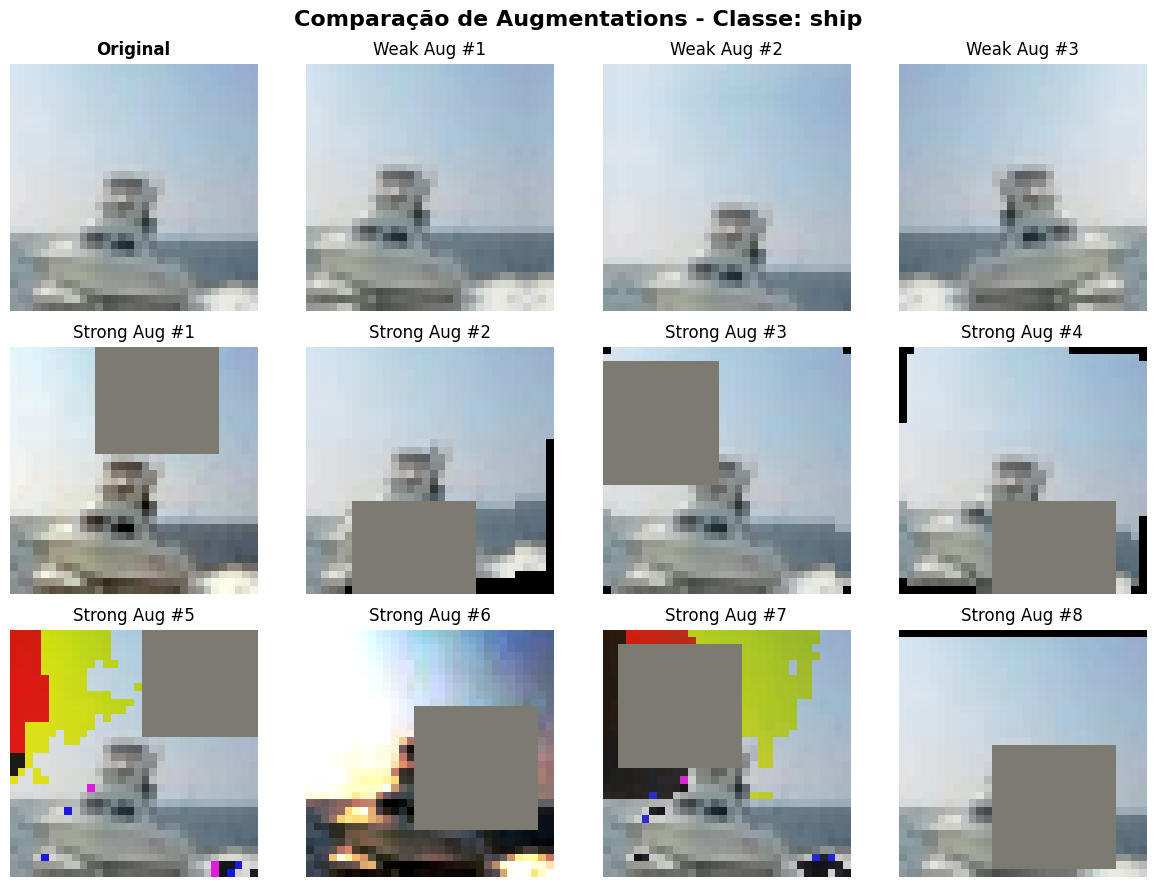

In [7]:
# Visualização das Augmentations

transform_base = transforms.Compose([transforms.ToTensor()])
cifar10_sample = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_base)

# imagem exemplo
sample_idx = 100
sample_img, sample_label = cifar10_sample[sample_idx]
sample_img_pil = transforms.ToPILImage()(sample_img)

# Classes do CIFAR-10
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Criar augmentations
weak_aug = WeakAugmentation()
strong_aug = StrongAugmentation()

# Função para desnormalizar imagem para visualização
def denormalize(tensor, mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]):
    """Desnormaliza um tensor para visualização"""
    tensor = tensor.clone()
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return torch.clamp(tensor, 0, 1)

# Gerar várias versões da mesma imagem
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
fig.suptitle(f'Comparação de Augmentations - Classe: {classes[sample_label]}', fontsize=16, fontweight='bold')

# Weak Augmentations
axes[0, 0].imshow(sample_img.permute(1, 2, 0))
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')

for i in range(1, 4):
    weak_img = weak_aug(sample_img_pil)
    weak_img_denorm = denormalize(weak_img)
    axes[0, i].imshow(weak_img_denorm.permute(1, 2, 0))
    axes[0, i].set_title(f'Weak Aug #{i}')
    axes[0, i].axis('off')

# 4 Strong Augmentations
for i in range(4):
    strong_img = strong_aug(sample_img_pil)
    strong_img_denorm = denormalize(strong_img)
    axes[1, i].imshow(strong_img_denorm.permute(1, 2, 0))
    axes[1, i].set_title(f'Strong Aug #{i+1}')
    axes[1, i].axis('off')

# mais variedade
for i in range(4):
    strong_img = strong_aug(sample_img_pil)
    strong_img_denorm = denormalize(strong_img)
    axes[2, i].imshow(strong_img_denorm.permute(1, 2, 0))
    axes[2, i].set_title(f'Strong Aug #{i+5}')
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

## 3. Dataset Loader com Split Rotulado/Não-Rotulado

O FixMatch precisa de dois tipos de dados:
- **Dados rotulados**: Pequeno conjunto com labels conhecidos (usado para loss supervisionada)
- **Dados não-rotulados**: Grande conjunto sem labels (usado para pseudo-labeling e loss não-supervisionada)

Vamos criar funções para:
1. Dividir o CIFAR-10 em rotulado/não-rotulado
2. Criar datasets customizados que aplicam weak e strong augmentations

### Labeled Dataset

In [8]:
class LabeledDataset(Dataset):
    """
    Dataset para dados rotulados.
    Aplica apenas weak augmentation.
    """
    def __init__(self, base_dataset, indices, transform=None):
        self.base_dataset = base_dataset
        self.indices = indices
        self.transform = transform if transform is not None else WeakAugmentation()

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Pegar imagem e label do dataset base
        real_idx = self.indices[idx]
        img_tensor, label = self.base_dataset[real_idx]

        # Converter tensor de volta para PIL para aplicar augmentation
        img_pil = transforms.ToPILImage()(img_tensor)

        # Aplicar weak augmentation
        img_augmented = self.transform(img_pil)

        return img_augmented, label


### Unlabeled Dataset

In [9]:
class UnlabeledDataset(Dataset):
    """
    Dataset para dados não-rotulados.
    Retorna DUAS versões da mesma imagem:
    - Weak augmentation (para gerar pseudo-label)
    - Strong augmentation (para treinar consistência)
    """
    def __init__(self, base_dataset, indices):
        self.base_dataset = base_dataset
        self.indices = indices
        self.weak_transform = WeakAugmentation()
        self.strong_transform = StrongAugmentation()

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Pegar imagem do dataset base
        real_idx = self.indices[idx]
        img_tensor, _ = self.base_dataset[real_idx]  # Ignoramos o label

        # Converter tensor para PIL
        img_pil = transforms.ToPILImage()(img_tensor)

        # Aplicar weak e strong augmentations na MESMA imagem
        img_weak = self.weak_transform(img_pil)
        img_strong = self.strong_transform(img_pil)

        return img_weak, img_strong

In [11]:
def split_labeled_unlabeled(dataset, num_labels_per_class, num_classes=10):
    """
    Divide o dataset em conjuntos rotulado e não-rotulado.
    """
    # Organizar índices por classe
    labels = np.array([dataset[i][1] for i in range(len(dataset))])

    labeled_indices = []
    unlabeled_indices = []

    for class_idx in range(num_classes):
        # Encontrar todos os índices desta classe
        class_indices = np.where(labels == class_idx)[0]

        # Embaralhar para seleção aleatória
        np.random.shuffle(class_indices)

        # Separar em rotulado e não-rotulado
        labeled_indices.extend(class_indices[:num_labels_per_class])
        unlabeled_indices.extend(class_indices[num_labels_per_class:])

    return labeled_indices, unlabeled_indices

base_dataset = cifar10_sample

In [12]:
def create_dataloaders(num_labels_per_class, batch_size=64, num_workers=2):
    """
    Cria DataLoaders para treino com FixMatch.
    """
    # Carregar dataset base
    transform_base = transforms.Compose([transforms.ToTensor()])

    train_dataset = torchvision.datasets.CIFAR10(
        root='./data',
        train=True,
        download=True,
        transform=transform_base
    )

    test_dataset = torchvision.datasets.CIFAR10(
        root='./data',
        train=False,
        download=True,
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                               std=[0.2470, 0.2435, 0.2616])
        ])
    )

    # Split rotulado/não-rotulado
    labeled_indices, unlabeled_indices = split_labeled_unlabeled(
        train_dataset,
        num_labels_per_class
    )

    # Criar datasets customizados
    labeled_dataset = LabeledDataset(train_dataset, labeled_indices)
    unlabeled_dataset = UnlabeledDataset(train_dataset, unlabeled_indices)

    # Criar DataLoaders
    labeled_loader = DataLoader(
        labeled_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        # Alterado para False para garantir que labeled_loader não seja vazio com poucos exemplos
        drop_last=False  
    )

    unlabeled_loader = DataLoader(
        unlabeled_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        drop_last=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    print(f"✓ DataLoaders criados para {num_labels_per_class} labels/classe:")
    print(f"  - Labeled batches: {len(labeled_loader)}")
    print(f"  - Unlabeled batches: {len(unlabeled_loader)}")
    print(f"  - Test batches: {len(test_loader)}")

    return labeled_loader, unlabeled_loader, test_loader



## 4. Modelo Base - ResNet-18

Vamos usar o ResNet-18 do torchvision, adaptado para CIFAR-10 (imagens 32x32).

**Modificações necessárias:**
- Trocar a primeira camada convolucional (de 7x7 para 3x3, stride 1)
- Remover o MaxPooling inicial
- Ajustar a camada final para 10 classes (CIFAR-10)

In [13]:
import torchvision.models as models

def get_resnet18_cifar10(num_classes=10):
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# Criar modelo
model = get_resnet18_cifar10(num_classes=10).to(device)

## 5. Função de Perda Híbrida do FixMatch

O FixMatch utiliza uma função de perda que combina:

1. **Loss Supervisionada (Ls)**: Cross-entropy nos dados rotulados
   - `Ls = CrossEntropy(modelo(x_labeled), y_true)`

2. **Loss Não-Supervisionada (Lu)**: Consistência de pseudo-labels
   - Gera pseudo-label na versão weak: `pseudo_label = argmax(modelo(x_weak))`
   - Aplica loss na versão strong: `Lu = CrossEntropy(modelo(x_strong), pseudo_label)`
   - **Apenas se confiança > threshold** (ex: max(prob) > 0.95)

3. **Loss Total**: `L = Ls + λu * Lu`
   - λu é o peso da loss não-supervisionada (geralmente 1.0)

In [14]:
def fixmatch_loss(logits_labeled, labels, logits_unlabeled_weak, logits_unlabeled_strong,
                  threshold=0.95, lambda_u=1.0):
    """
    Calcula a loss híbrida do FixMatch.
    """
    # ===== 1. LOSS SUPERVISIONADA =====
    loss_supervised = F.cross_entropy(logits_labeled, labels)

    # ===== 2. LOSS NÃO-SUPERVISIONADA (PSEUDO-LABELING) =====
    # Gerar pseudo-labels da versão weak
    with torch.no_grad():
        probs_weak = F.softmax(logits_unlabeled_weak, dim=1)

        # Pegar a classe com maior probabilidade
        max_probs, pseudo_labels = torch.max(probs_weak, dim=1)

        # apenas amostras com confiança > threshold
        mask = max_probs >= threshold

    # Calcular loss apenas nas amostras que passaram no threshold
    if mask.sum() > 0:
        loss_unsupervised = F.cross_entropy(
            logits_unlabeled_strong[mask],
            pseudo_labels[mask]
        )
    else:
        # Se nenhuma amostra passou no threshold, loss = 0
        loss_unsupervised = torch.tensor(0.0).to(logits_labeled.device)

    # ===== 3. LOSS TOTAL =====
    loss_total = loss_supervised + lambda_u * loss_unsupervised

    # Calcular proporção de amostras usadas (para monitoramento)
    mask_ratio = mask.float().mean().item()

    return loss_total, loss_supervised, loss_unsupervised, mask_ratio



## 6. Função de Avaliação

Função para avaliar a acurácia do modelo no conjunto de teste.

In [15]:
@torch.no_grad()
def evaluate(model, test_loader, device):
    """
    Avalia o modelo no conjunto de teste.
    """
    model.eval()

    correct = 0
    total = 0

    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100.0 * correct / total

    return accuracy

## 7. Loop de Treinamento FixMatch

Implementação do loop de treinamento completo do FixMatch.

In [16]:
def train_fixmatch(model, labeled_loader, unlabeled_loader, test_loader,
                   num_epochs=100, lr=0.03, threshold=0.95, lambda_u=1.0, device='cpu'):
    """
    Treina o modelo usando o algoritmo FixMatch.
    """
    # Configurar otimizador e scheduler
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)

    # Cosine annealing scheduler
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    # Histórico
    history = {
        'train_loss': [],
        'train_loss_supervised': [],
        'train_loss_unsupervised': [],
        'mask_ratio': [],
        'test_accuracy': [],
        'learning_rate': []
    }

    # Loop de treinamento
    for epoch in range(num_epochs):
        model.train()

        # Métricas da época
        epoch_loss = 0.0
        epoch_loss_sup = 0.0
        epoch_loss_unsup = 0.0
        epoch_mask_ratio = 0.0
        num_batches = 0

        # Iteradores
        labeled_iter = iter(labeled_loader)
        unlabeled_iter = iter(unlabeled_loader)

        # Número de iterações = min(labeled_batches, unlabeled_batches)
        num_iterations = min(len(labeled_loader), len(unlabeled_loader))

        pbar = tqdm(range(num_iterations), desc=f'Epoch {epoch+1}/{num_epochs}')

        for _ in pbar:
            try:
                # Dados rotulados
                images_labeled, labels_labeled = next(labeled_iter)
            except StopIteration:
                labeled_iter = iter(labeled_loader)
                images_labeled, labels_labeled = next(labeled_iter)

            try:
                # Dados não-rotulados (weak e strong)
                images_unlabeled_weak, images_unlabeled_strong = next(unlabeled_iter)
            except StopIteration:
                unlabeled_iter = iter(unlabeled_loader)
                images_unlabeled_weak, images_unlabeled_strong = next(unlabeled_iter)

            # Mover para device
            images_labeled = images_labeled.to(device)
            labels_labeled = labels_labeled.to(device)
            images_unlabeled_weak = images_unlabeled_weak.to(device)
            images_unlabeled_strong = images_unlabeled_strong.to(device)

            # Dados rotulados
            logits_labeled = model(images_labeled)

            # Dados não-rotulados (weak e strong)
            logits_unlabeled_weak = model(images_unlabeled_weak)
            logits_unlabeled_strong = model(images_unlabeled_strong)

            loss, loss_sup, loss_unsup, mask_ratio = fixmatch_loss(
                logits_labeled, labels_labeled,
                logits_unlabeled_weak, logits_unlabeled_strong,
                threshold=threshold, lambda_u=lambda_u
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_loss_sup += loss_sup.item()
            epoch_loss_unsup += loss_unsup.item()
            epoch_mask_ratio += mask_ratio
            num_batches += 1

            # Atualizar progress bar
            pbar.set_postfix({
                'Loss': f'{loss.item():.3f}',
                'Ls': f'{loss_sup.item():.3f}',
                'Lu': f'{loss_unsup.item():.3f}',
                'Mask': f'{mask_ratio:.2%}'
            })

        scheduler.step()

        avg_loss = epoch_loss / num_batches
        avg_loss_sup = epoch_loss_sup / num_batches
        avg_loss_unsup = epoch_loss_unsup / num_batches
        avg_mask_ratio = epoch_mask_ratio / num_batches

        test_acc = evaluate(model, test_loader, device)

        history['train_loss'].append(avg_loss)
        history['train_loss_supervised'].append(avg_loss_sup)
        history['train_loss_unsupervised'].append(avg_loss_unsup)
        history['mask_ratio'].append(avg_mask_ratio)
        history['test_accuracy'].append(test_acc)
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])

        # resumo da época
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'  Loss: {avg_loss:.4f} (Sup: {avg_loss_sup:.4f}, Unsup: {avg_loss_unsup:.4f})')
        print(f'  Mask Ratio: {avg_mask_ratio:.2%}')
        print(f'  Test Accuracy: {test_acc:.2f}%')
        print(f'  LR: {optimizer.param_groups[0]["lr"]:.6f}')
        print('-' * 60)

    return history

## Variando threshold

EXPERIMENTO 3: 25 RÓTULOS POR CLASSE
Configurações:
  - Rótulos por classe: 25
  - Total de rótulos: 250
  - Batch size: 256
  - Épocas: 50
  - Learning rate: 0.03
✓ DataLoaders criados para 25 labels/classe:
  - Labeled batches: 1
  - Unlabeled batches: 194
  - Test batches: 40


Epoch 1/50: 100%|██████████| 1/1 [00:01<00:00,  1.50s/it, Loss=2.372, Ls=2.372, Lu=0.000, Mask=0.00%]


Epoch 1/50:
  Loss: 2.3716 (Sup: 2.3716, Unsup: 0.0000)
  Mask Ratio: 0.00%
  Test Accuracy: 12.58%
  LR: 0.029970
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 1/1 [00:00<00:00,  1.38it/s, Loss=2.267, Ls=2.267, Lu=0.000, Mask=0.00%]


Epoch 2/50:
  Loss: 2.2669 (Sup: 2.2669, Unsup: 0.0000)
  Mask Ratio: 0.00%
  Test Accuracy: 16.85%
  LR: 0.029882
------------------------------------------------------------


...

Epoch 48/50:
  Loss: 2.2657 (Sup: 1.9679, Unsup: 0.2979)
  Mask Ratio: 35.94%
  Test Accuracy: 15.13%
  LR: 0.000118
------------------------------------------------------------


Epoch 49/50: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s, Loss=2.271, Ls=1.976, Lu=0.295, Mask=29.69%]


Epoch 49/50:
  Loss: 2.2714 (Sup: 1.9761, Unsup: 0.2953)
  Mask Ratio: 29.69%
  Test Accuracy: 15.10%
  LR: 0.000030
------------------------------------------------------------


Epoch 50/50: 100%|██████████| 1/1 [00:00<00:00,  1.24it/s, Loss=2.172, Ls=1.997, Lu=0.176, Mask=54.69%]


Epoch 50/50:
  Loss: 2.1722 (Sup: 1.9965, Unsup: 0.1756)
  Mask Ratio: 54.69%
  Test Accuracy: 14.76%
  LR: 0.000000
------------------------------------------------------------


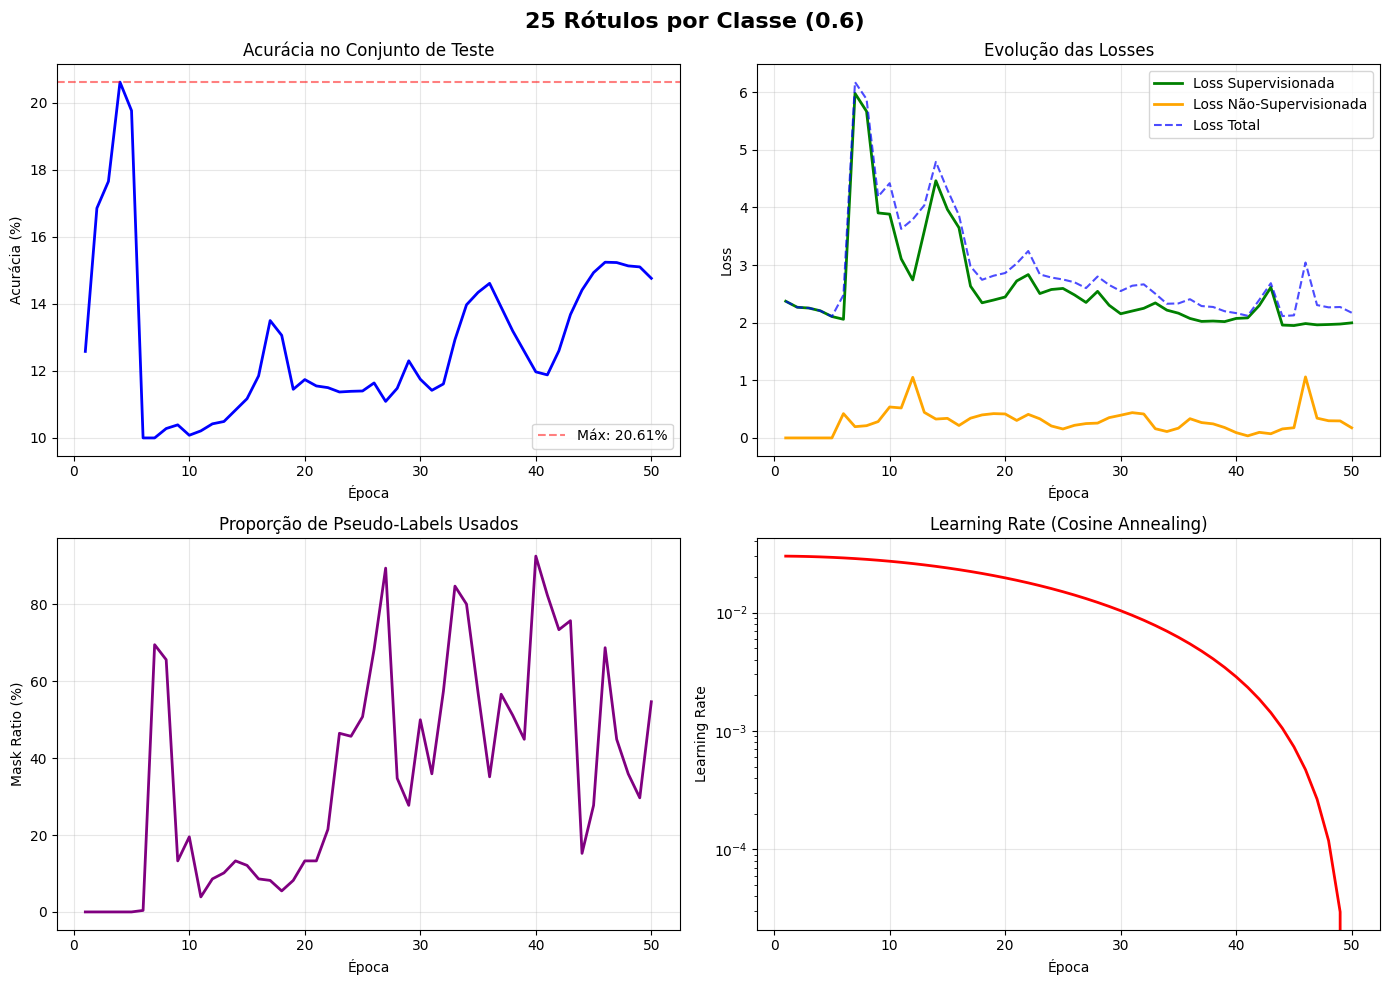

Epoch 1/50: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s, Loss=2.157, Ls=2.014, Lu=0.142, Mask=40.23%]


Epoch 1/50:
  Loss: 2.1565 (Sup: 2.0143, Unsup: 0.1423)
  Mask Ratio: 40.23%
  Test Accuracy: 14.57%
  LR: 0.029970
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s, Loss=2.122, Ls=1.937, Lu=0.185, Mask=5.47%]


Epoch 2/50:
  Loss: 2.1220 (Sup: 1.9370, Unsup: 0.1850)
  Mask Ratio: 5.47%
  Test Accuracy: 11.47%
  LR: 0.029882
------------------------------------------------------------


Epoch 3/50: 100%|██████████| 1/1 [00:00<00:00,  1.24it/s, Loss=3.591, Ls=3.472, Lu=0.118, Mask=58.98%]


...

Epoch 48/50:
  Loss: 1.7075 (Sup: 1.6257, Unsup: 0.0818)
  Mask Ratio: 84.38%
  Test Accuracy: 12.60%
  LR: 0.000118
------------------------------------------------------------


Epoch 49/50: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s, Loss=1.718, Ls=1.663, Lu=0.055, Mask=64.45%]


Epoch 49/50:
  Loss: 1.7180 (Sup: 1.6630, Unsup: 0.0550)
  Mask Ratio: 64.45%
  Test Accuracy: 12.56%
  LR: 0.000030
------------------------------------------------------------


Epoch 50/50: 100%|██████████| 1/1 [00:00<00:00,  1.24it/s, Loss=1.706, Ls=1.637, Lu=0.068, Mask=25.78%]


Epoch 50/50:
  Loss: 1.7060 (Sup: 1.6375, Unsup: 0.0685)
  Mask Ratio: 25.78%
  Test Accuracy: 12.74%
  LR: 0.000000
------------------------------------------------------------


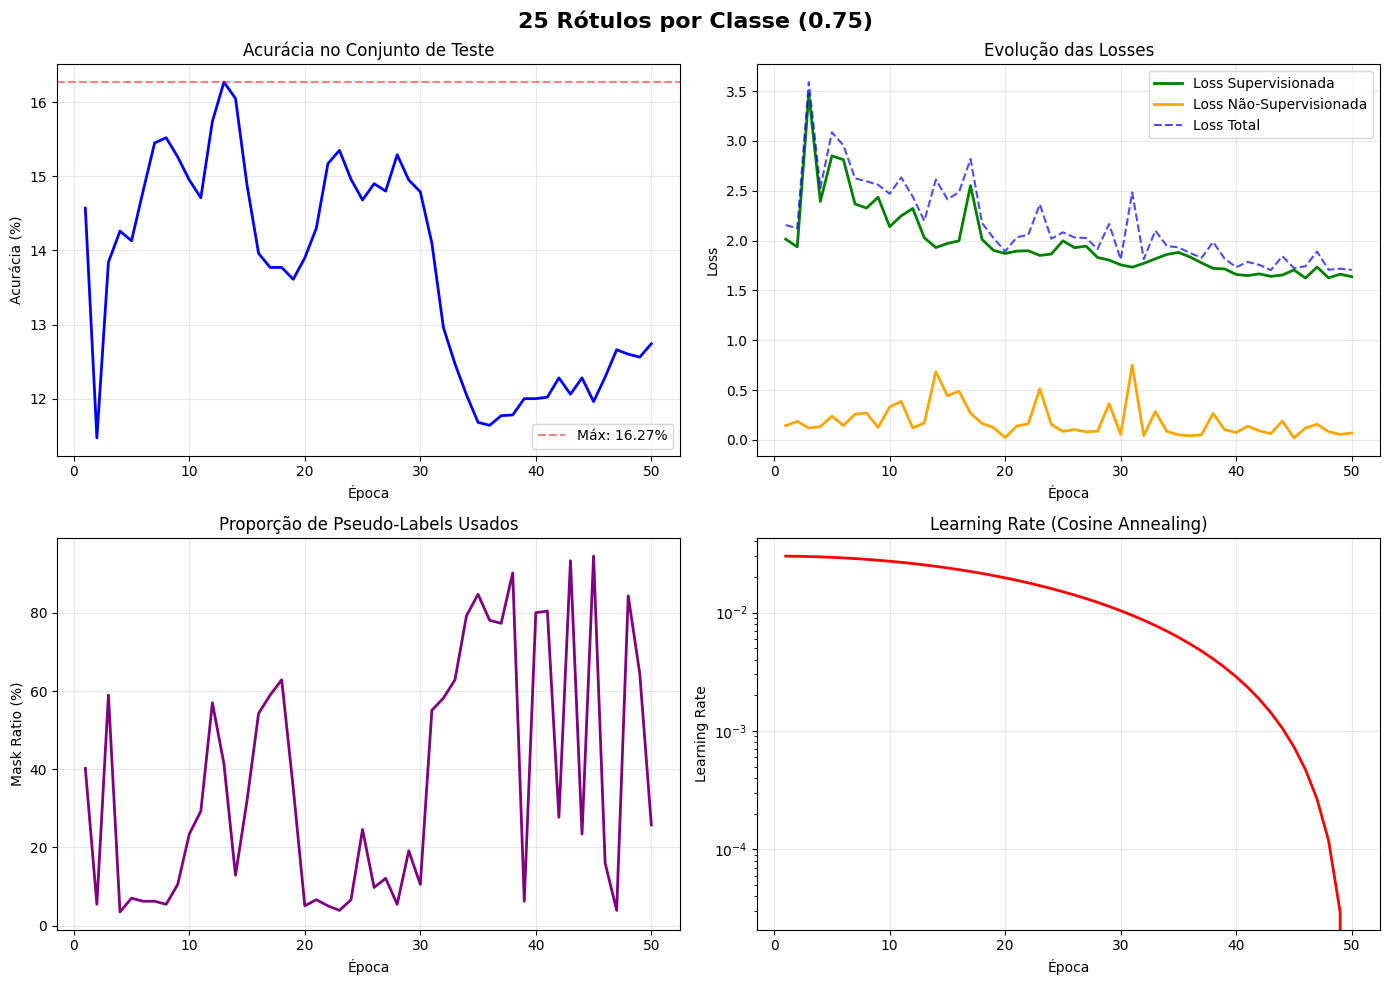

Epoch 1/50: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s, Loss=1.673, Ls=1.628, Lu=0.044, Mask=1.56%]


Epoch 1/50:
  Loss: 1.6725 (Sup: 1.6283, Unsup: 0.0442)
  Mask Ratio: 1.56%
  Test Accuracy: 13.91%
  LR: 0.029970
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s, Loss=1.643, Ls=1.600, Lu=0.043, Mask=10.94%]


Epoch 2/50:
  Loss: 1.6428 (Sup: 1.5996, Unsup: 0.0432)
  Mask Ratio: 10.94%
  Test Accuracy: 15.08%
  LR: 0.029882
------------------------------------------------------------


Epoch 3/50: 100%|██████████| 1/1 [00:00<00:00,  1.21it/s, Loss=1.647, Ls=1.614, Lu=0.033, Mask=12.89%]


...

Epoch 48/50:
  Loss: 1.0628 (Sup: 0.9708, Unsup: 0.0920)
  Mask Ratio: 14.06%
  Test Accuracy: 15.99%
  LR: 0.000118
------------------------------------------------------------


Epoch 49/50: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s, Loss=0.957, Ls=0.939, Lu=0.017, Mask=78.91%]


Epoch 49/50:
  Loss: 0.9565 (Sup: 0.9392, Unsup: 0.0173)
  Mask Ratio: 78.91%
  Test Accuracy: 15.29%
  LR: 0.000030
------------------------------------------------------------


Epoch 50/50: 100%|██████████| 1/1 [00:00<00:00,  1.24it/s, Loss=0.962, Ls=0.949, Lu=0.013, Mask=47.27%]


Epoch 50/50:
  Loss: 0.9623 (Sup: 0.9490, Unsup: 0.0133)
  Mask Ratio: 47.27%
  Test Accuracy: 15.26%
  LR: 0.000000
------------------------------------------------------------


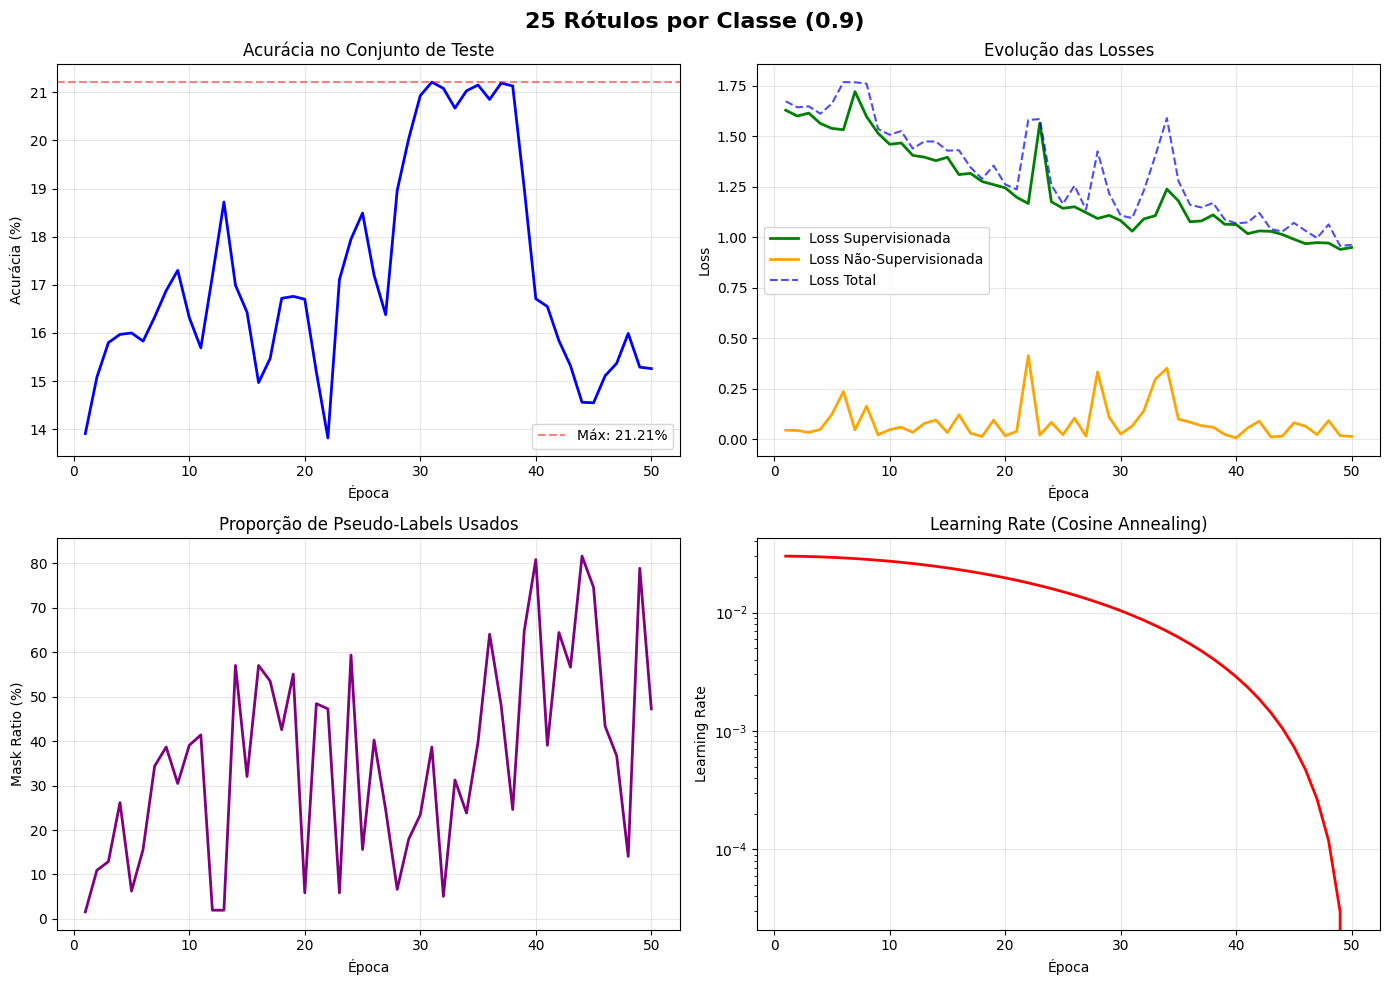

Epoch 1/50: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s, Loss=0.959, Ls=0.950, Lu=0.009, Mask=64.06%]


Epoch 1/50:
  Loss: 0.9587 (Sup: 0.9500, Unsup: 0.0086)
  Mask Ratio: 64.06%
  Test Accuracy: 15.03%
  LR: 0.029970
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s, Loss=0.984, Ls=0.967, Lu=0.017, Mask=14.84%]


Epoch 2/50:
  Loss: 0.9844 (Sup: 0.9670, Unsup: 0.0173)
  Mask Ratio: 14.84%
  Test Accuracy: 16.99%
  LR: 0.029882
------------------------------------------------------------


Epoch 3/50: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s, Loss=1.085, Ls=0.925, Lu=0.160, Mask=12.11%]


...

Epoch 48/50:
  Loss: 0.7883 (Sup: 0.7069, Unsup: 0.0815)
  Mask Ratio: 57.81%
  Test Accuracy: 19.62%
  LR: 0.000118
------------------------------------------------------------


Epoch 49/50: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s, Loss=0.821, Ls=0.749, Lu=0.072, Mask=55.86%]


Epoch 49/50:
  Loss: 0.8211 (Sup: 0.7494, Unsup: 0.0717)
  Mask Ratio: 55.86%
  Test Accuracy: 19.42%
  LR: 0.000030
------------------------------------------------------------


Epoch 50/50: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s, Loss=0.744, Ls=0.708, Lu=0.036, Mask=32.42%]


Epoch 50/50:
  Loss: 0.7439 (Sup: 0.7075, Unsup: 0.0363)
  Mask Ratio: 32.42%
  Test Accuracy: 19.00%
  LR: 0.000000
------------------------------------------------------------


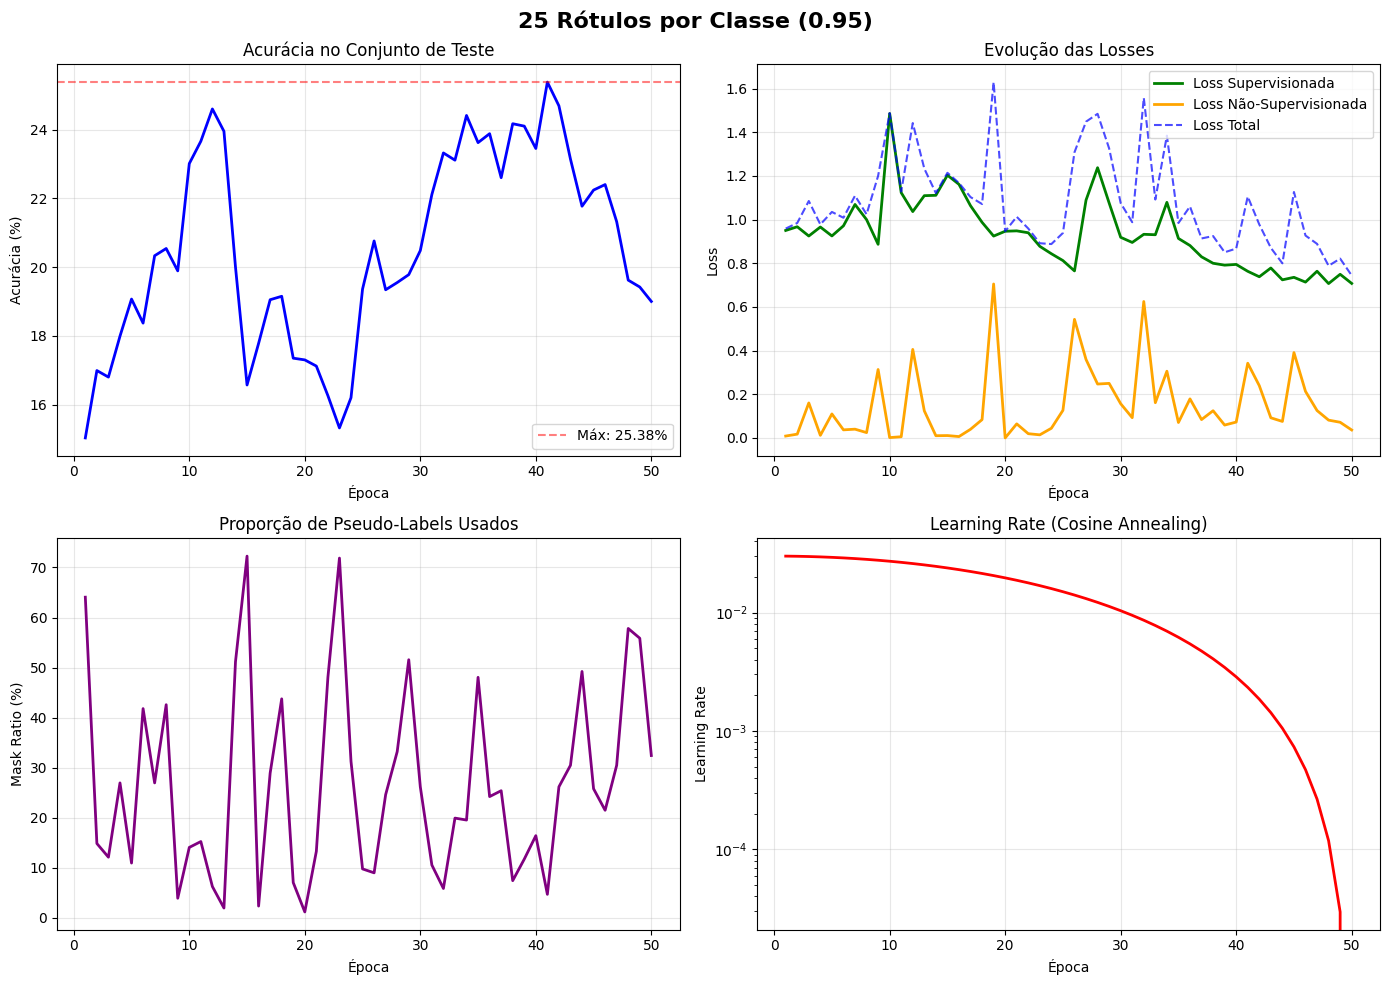

Epoch 1/50: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s, Loss=0.754, Ls=0.743, Lu=0.011, Mask=9.38%]


Epoch 1/50:
  Loss: 0.7544 (Sup: 0.7434, Unsup: 0.0109)
  Mask Ratio: 9.38%
  Test Accuracy: 19.97%
  LR: 0.029970
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 1/1 [00:00<00:00,  1.23it/s, Loss=1.538, Ls=0.685, Lu=0.853, Mask=2.73%]


Epoch 2/50:
  Loss: 1.5384 (Sup: 0.6852, Unsup: 0.8533)
  Mask Ratio: 2.73%
  Test Accuracy: 20.55%
  LR: 0.029882
------------------------------------------------------------


Epoch 3/50: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s, Loss=1.044, Ls=0.955, Lu=0.088, Mask=5.08%]


...

Epoch 48/50:
  Loss: 0.9724 (Sup: 0.8638, Unsup: 0.1085)
  Mask Ratio: 5.86%
  Test Accuracy: 27.04%
  LR: 0.000118
------------------------------------------------------------


Epoch 49/50: 100%|██████████| 1/1 [00:00<00:00,  1.30it/s, Loss=0.879, Ls=0.854, Lu=0.025, Mask=6.25%]


Epoch 49/50:
  Loss: 0.8789 (Sup: 0.8543, Unsup: 0.0245)
  Mask Ratio: 6.25%
  Test Accuracy: 26.23%
  LR: 0.000030
------------------------------------------------------------


Epoch 50/50: 100%|██████████| 1/1 [00:00<00:00,  1.30it/s, Loss=0.882, Ls=0.868, Lu=0.013, Mask=9.77%]


Epoch 50/50:
  Loss: 0.8816 (Sup: 0.8683, Unsup: 0.0133)
  Mask Ratio: 9.77%
  Test Accuracy: 25.03%
  LR: 0.000000
------------------------------------------------------------


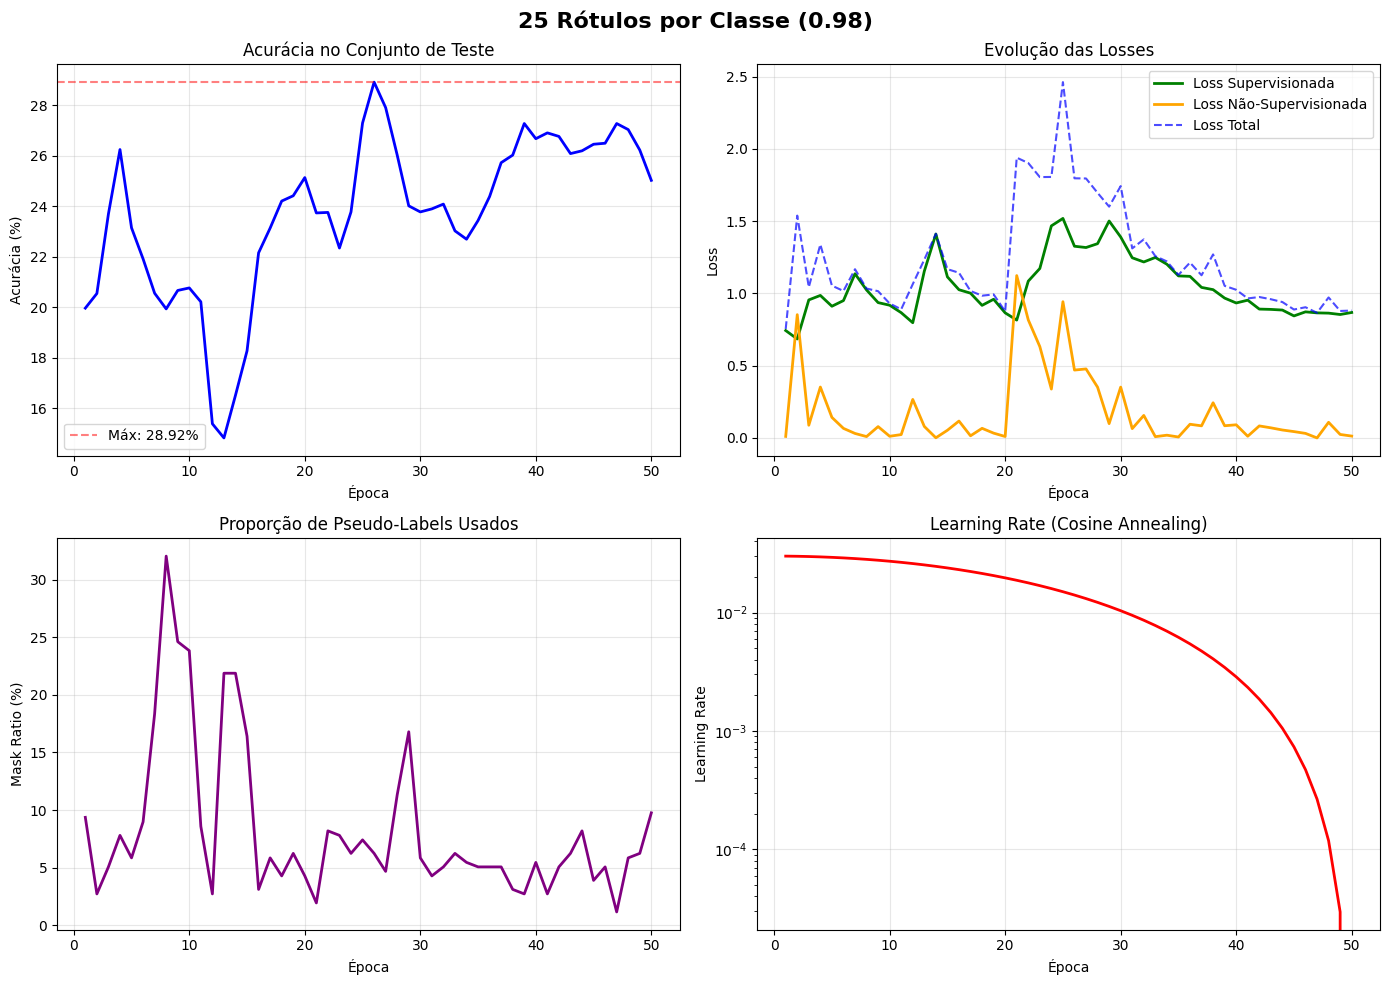

In [ ]:
# ===== CONFIGURAÇÕES DO EXPERIMENTO  =====
NUM_LABELS_PER_CLASS = 25
BATCH_SIZE = 256
NUM_EPOCHS = 50
LEARNING_RATE = 0.03
LAMBDA_U = 1.0

print("="*60)
print("EXPERIMENTO 3: 25 RÓTULOS POR CLASSE")
print("="*60)
print(f"Configurações:")
print(f"  - Rótulos por classe: {NUM_LABELS_PER_CLASS}")
print(f"  - Total de rótulos: {NUM_LABELS_PER_CLASS * 10}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Épocas: {NUM_EPOCHS}")
print(f"  - Learning rate: {LEARNING_RATE}")
print("="*60)


# ===== CRIAR DATALOADERS =====
labeled_loader_25, unlabeled_loader_25, test_loader_25 = create_dataloaders(
    num_labels_per_class=NUM_LABELS_PER_CLASS,
    batch_size=BATCH_SIZE,
    num_workers=0)

# ===== CRIAR MODELO =====
model_25label = get_resnet18_cifar10(num_classes=10).to(device)

thresholds = [0.6, 0.75, 0.9, 0.95, 0.98]
for tau in thresholds:
    history_25label = train_fixmatch(
    model=model_25label,
    labeled_loader=labeled_loader_25,
    unlabeled_loader=unlabeled_loader_25,
    test_loader=test_loader_25,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    threshold=tau,
    lambda_u=LAMBDA_U,
    device=device
    )
    # Visualizar resultados do Experimento 4
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'25 Rótulos por Classe ({tau})', fontsize=16, fontweight='bold')
    
    epochs = range(1, len(history_25label['test_accuracy']) + 1)
    
    # 1. Acurácia no Teste
    axes[0, 0].plot(epochs, history_25label['test_accuracy'], 'b-', linewidth=2)
    axes[0, 0].set_xlabel('Época')
    axes[0, 0].set_ylabel('Acurácia (%)')
    axes[0, 0].set_title('Acurácia no Conjunto de Teste')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axhline(y=max(history_25label['test_accuracy']), color='r', linestyle='--',
                        alpha=0.5, label=f'Máx: {max(history_25label["test_accuracy"]):.2f}%')
    axes[0, 0].legend()
    
    # 2. Losses
    axes[0, 1].plot(epochs, history_25label['train_loss_supervised'], 'g-', linewidth=2, label='Loss Supervisionada')
    axes[0, 1].plot(epochs, history_25label['train_loss_unsupervised'], 'orange', linewidth=2, label='Loss Não-Supervisionada')
    axes[0, 1].plot(epochs, history_25label['train_loss'], 'b--', linewidth=1.5, label='Loss Total', alpha=0.7)
    axes[0, 1].set_xlabel('Época')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_title('Evolução das Losses')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Mask Ratio
    axes[1, 0].plot(epochs, [m * 100 for m in history_25label['mask_ratio']], 'purple', linewidth=2)
    axes[1, 0].set_xlabel('Época')
    axes[1, 0].set_ylabel('Mask Ratio (%)')
    axes[1, 0].set_title('Proporção de Pseudo-Labels Usados')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Learning Rate
    axes[1, 1].plot(epochs, history_25label['learning_rate'], 'red', linewidth=2)
    axes[1, 1].set_xlabel('Época')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate (Cosine Annealing)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_yscale('log')
    
    plt.tight_layout()
    plt.show()

## Variando o $\lambda_u$

EXPERIMENTO 3: 25 RÓTULOS POR CLASSE
Configurações:
  - Rótulos por classe: 25
  - Total de rótulos: 250
  - Batch size: 256
  - Épocas: 50
  - Learning rate: 0.03
✓ DataLoaders criados para 25 labels/classe:
  - Labeled batches: 1
  - Unlabeled batches: 194
  - Test batches: 40


Epoch 1/50: 100%|██████████| 1/1 [00:01<00:00,  1.69s/it, Loss=2.382, Ls=2.382, Lu=0.000, Mask=0.00%]


Epoch 1/50:
  Loss: 2.3823 (Sup: 2.3823, Unsup: 0.0000)
  Mask Ratio: 0.00%
  Test Accuracy: 7.80%
  LR: 0.029970
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 1/1 [00:00<00:00,  1.33it/s, Loss=2.305, Ls=2.305, Lu=0.000, Mask=0.00%]


Epoch 2/50:
  Loss: 2.3053 (Sup: 2.3053, Unsup: 0.0000)
  Mask Ratio: 0.00%
  Test Accuracy: 9.64%
  LR: 0.029882
------------------------------------------------------------


...

Epoch 48/50:
  Loss: 1.1169 (Sup: 0.9078, Unsup: 0.4182)
  Mask Ratio: 7.42%
  Test Accuracy: 31.69%
  LR: 0.000118
------------------------------------------------------------


Epoch 49/50: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s, Loss=1.040, Ls=0.895, Lu=0.289, Mask=4.30%]


Epoch 49/50:
  Loss: 1.0400 (Sup: 0.8955, Unsup: 0.2890)
  Mask Ratio: 4.30%
  Test Accuracy: 31.93%
  LR: 0.000030
------------------------------------------------------------


Epoch 50/50: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s, Loss=1.005, Ls=0.899, Lu=0.212, Mask=5.86%]


Epoch 50/50:
  Loss: 1.0053 (Sup: 0.8992, Unsup: 0.2122)
  Mask Ratio: 5.86%
  Test Accuracy: 32.07%
  LR: 0.000000
------------------------------------------------------------


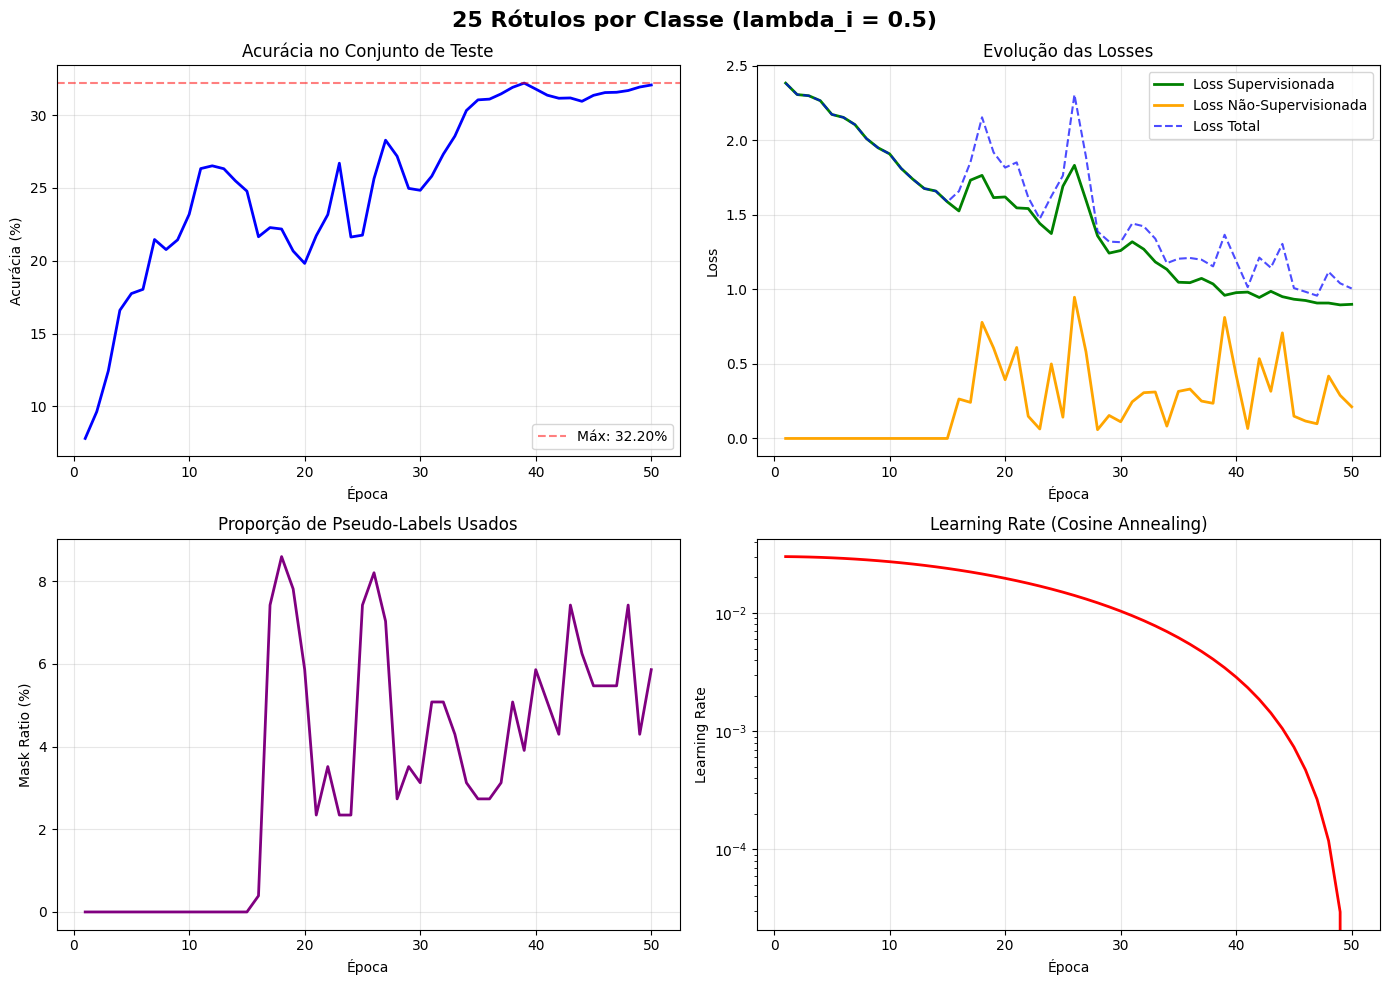

Epoch 1/50: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s, Loss=1.537, Ls=0.934, Lu=0.603, Mask=5.47%]


Epoch 1/50:
  Loss: 1.5372 (Sup: 0.9339, Unsup: 0.6033)
  Mask Ratio: 5.47%
  Test Accuracy: 26.10%
  LR: 0.029970
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 1/1 [00:00<00:00,  1.24it/s, Loss=1.461, Ls=1.127, Lu=0.334, Mask=5.86%]


Epoch 2/50:
  Loss: 1.4606 (Sup: 1.1270, Unsup: 0.3336)
  Mask Ratio: 5.86%
  Test Accuracy: 24.10%
  LR: 0.029882
------------------------------------------------------------


Epoch 3/50: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s, Loss=1.719, Ls=1.508, Lu=0.211, Mask=9.77%]


...

Epoch 48/50:
  Loss: 1.1583 (Sup: 1.0113, Unsup: 0.1470)
  Mask Ratio: 9.38%
  Test Accuracy: 32.39%
  LR: 0.000118
------------------------------------------------------------


Epoch 49/50: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s, Loss=1.432, Ls=1.050, Lu=0.382, Mask=11.33%]


Epoch 49/50:
  Loss: 1.4324 (Sup: 1.0504, Unsup: 0.3820)
  Mask Ratio: 11.33%
  Test Accuracy: 32.44%
  LR: 0.000030
------------------------------------------------------------


Epoch 50/50: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s, Loss=1.173, Ls=1.040, Lu=0.133, Mask=8.98%]


Epoch 50/50:
  Loss: 1.1732 (Sup: 1.0400, Unsup: 0.1332)
  Mask Ratio: 8.98%
  Test Accuracy: 32.41%
  LR: 0.000000
------------------------------------------------------------


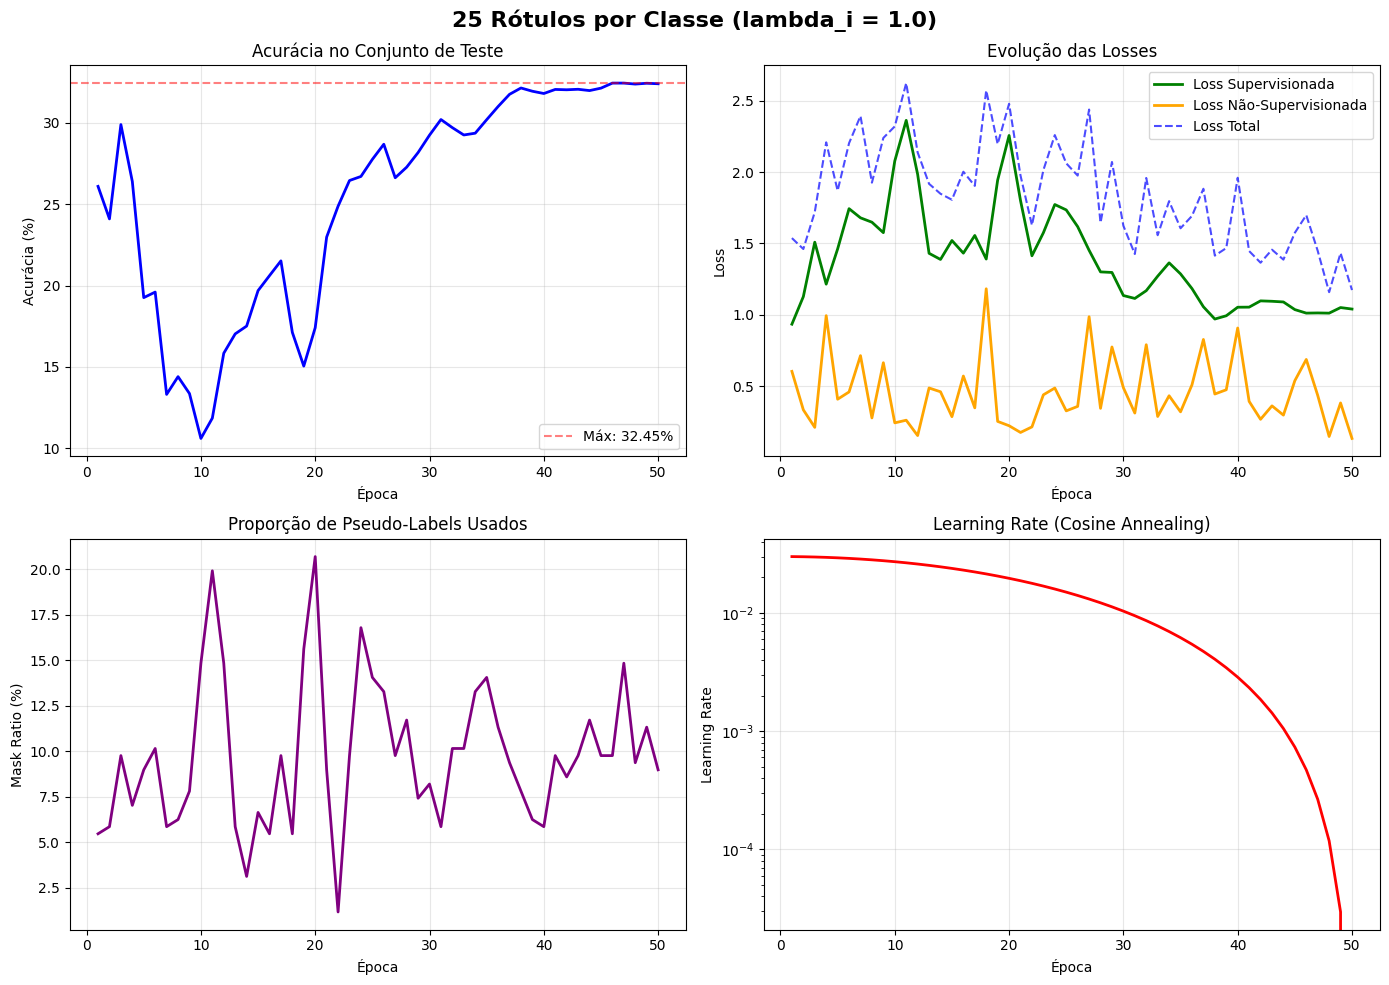

Epoch 1/50: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s, Loss=1.821, Ls=1.012, Lu=0.405, Mask=9.38%]


Epoch 1/50:
  Loss: 1.8208 (Sup: 1.0116, Unsup: 0.4046)
  Mask Ratio: 9.38%
  Test Accuracy: 24.16%
  LR: 0.029970
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s, Loss=2.322, Ls=1.223, Lu=0.550, Mask=12.11%]


Epoch 2/50:
  Loss: 2.3221 (Sup: 1.2226, Unsup: 0.5497)
  Mask Ratio: 12.11%
  Test Accuracy: 23.16%
  LR: 0.029882
------------------------------------------------------------


Epoch 3/50: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s, Loss=2.355, Ls=1.744, Lu=0.306, Mask=23.83%]


...

Epoch 48/50:
  Loss: 2.3186 (Sup: 2.0161, Unsup: 0.1512)
  Mask Ratio: 14.84%
  Test Accuracy: 27.24%
  LR: 0.000118
------------------------------------------------------------


Epoch 49/50: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s, Loss=2.222, Ls=2.004, Lu=0.109, Mask=11.33%]


Epoch 49/50:
  Loss: 2.2222 (Sup: 2.0043, Unsup: 0.1089)
  Mask Ratio: 11.33%
  Test Accuracy: 27.23%
  LR: 0.000030
------------------------------------------------------------


Epoch 50/50: 100%|██████████| 1/1 [00:00<00:00,  1.30it/s, Loss=2.202, Ls=1.967, Lu=0.118, Mask=12.50%]


Epoch 50/50:
  Loss: 2.2025 (Sup: 1.9674, Unsup: 0.1175)
  Mask Ratio: 12.50%
  Test Accuracy: 27.15%
  LR: 0.000000
------------------------------------------------------------


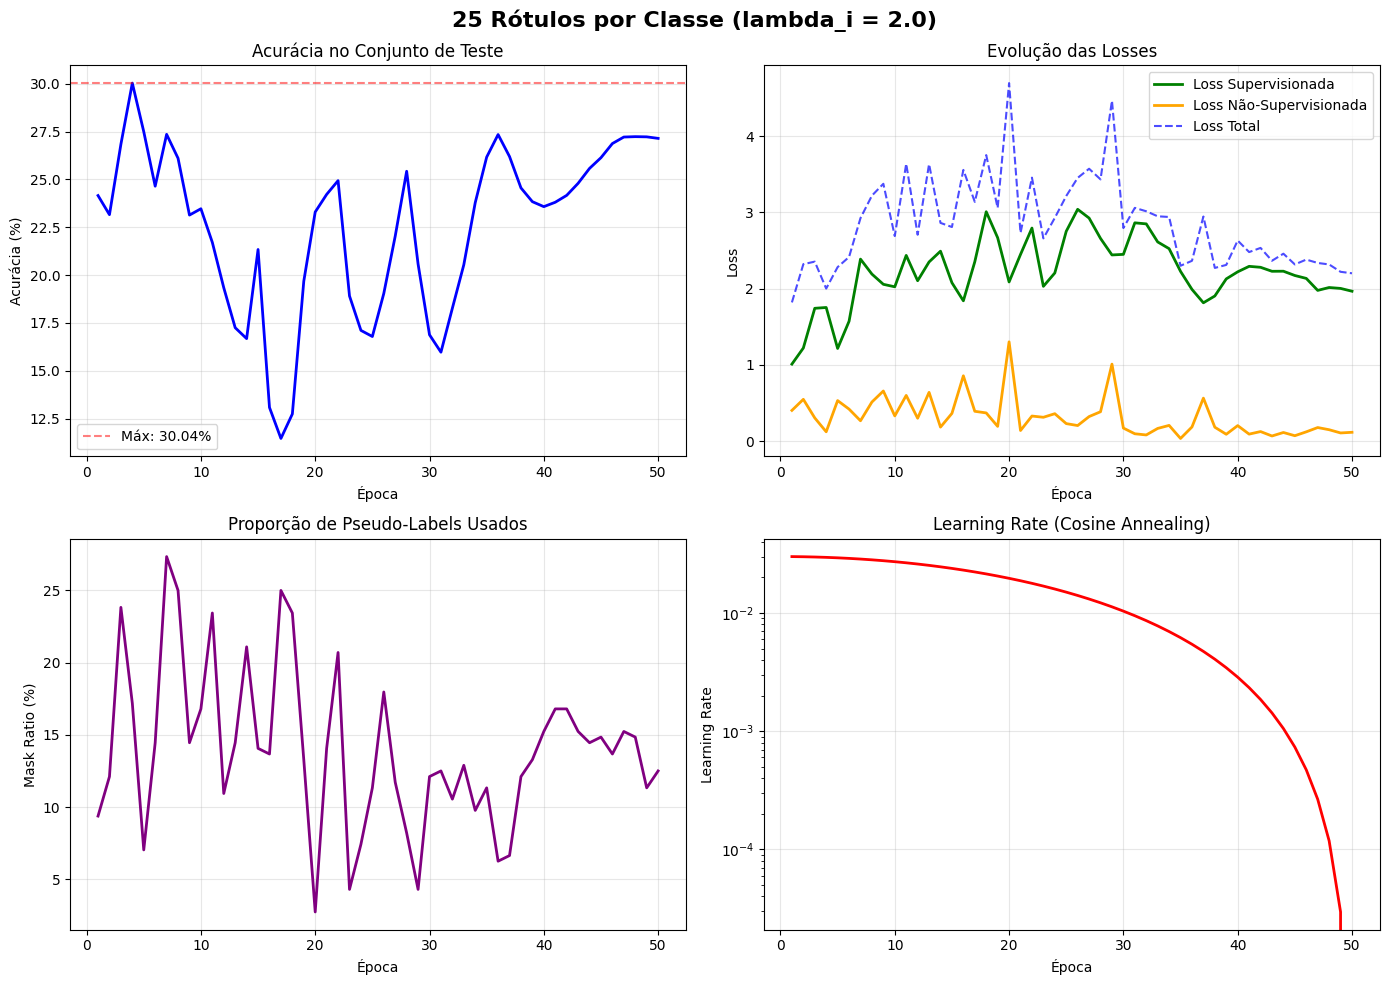

Epoch 1/50: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s, Loss=3.033, Ls=1.916, Lu=0.223, Mask=16.41%]


Epoch 1/50:
  Loss: 3.0331 (Sup: 1.9159, Unsup: 0.2235)
  Mask Ratio: 16.41%
  Test Accuracy: 15.43%
  LR: 0.029970
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s, Loss=2.864, Ls=2.716, Lu=0.030, Mask=17.19%]


Epoch 2/50:
  Loss: 2.8639 (Sup: 2.7157, Unsup: 0.0296)
  Mask Ratio: 17.19%
  Test Accuracy: 15.97%
  LR: 0.029882
------------------------------------------------------------


Epoch 3/50: 100%|██████████| 1/1 [00:00<00:00,  1.27it/s, Loss=2.804, Ls=2.567, Lu=0.047, Mask=21.09%]


...

Epoch 48/50:
  Loss: 2.9113 (Sup: 2.7343, Unsup: 0.0354)
  Mask Ratio: 30.47%
  Test Accuracy: 10.00%
  LR: 0.000118
------------------------------------------------------------


Epoch 49/50: 100%|██████████| 1/1 [00:00<00:00,  1.24it/s, Loss=3.209, Ls=3.037, Lu=0.034, Mask=23.83%]


Epoch 49/50:
  Loss: 3.2086 (Sup: 3.0372, Unsup: 0.0343)
  Mask Ratio: 23.83%
  Test Accuracy: 10.00%
  LR: 0.000030
------------------------------------------------------------


Epoch 50/50: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s, Loss=3.210, Ls=2.948, Lu=0.053, Mask=6.25%]


Epoch 50/50:
  Loss: 3.2105 (Sup: 2.9480, Unsup: 0.0525)
  Mask Ratio: 6.25%
  Test Accuracy: 10.00%
  LR: 0.000000
------------------------------------------------------------


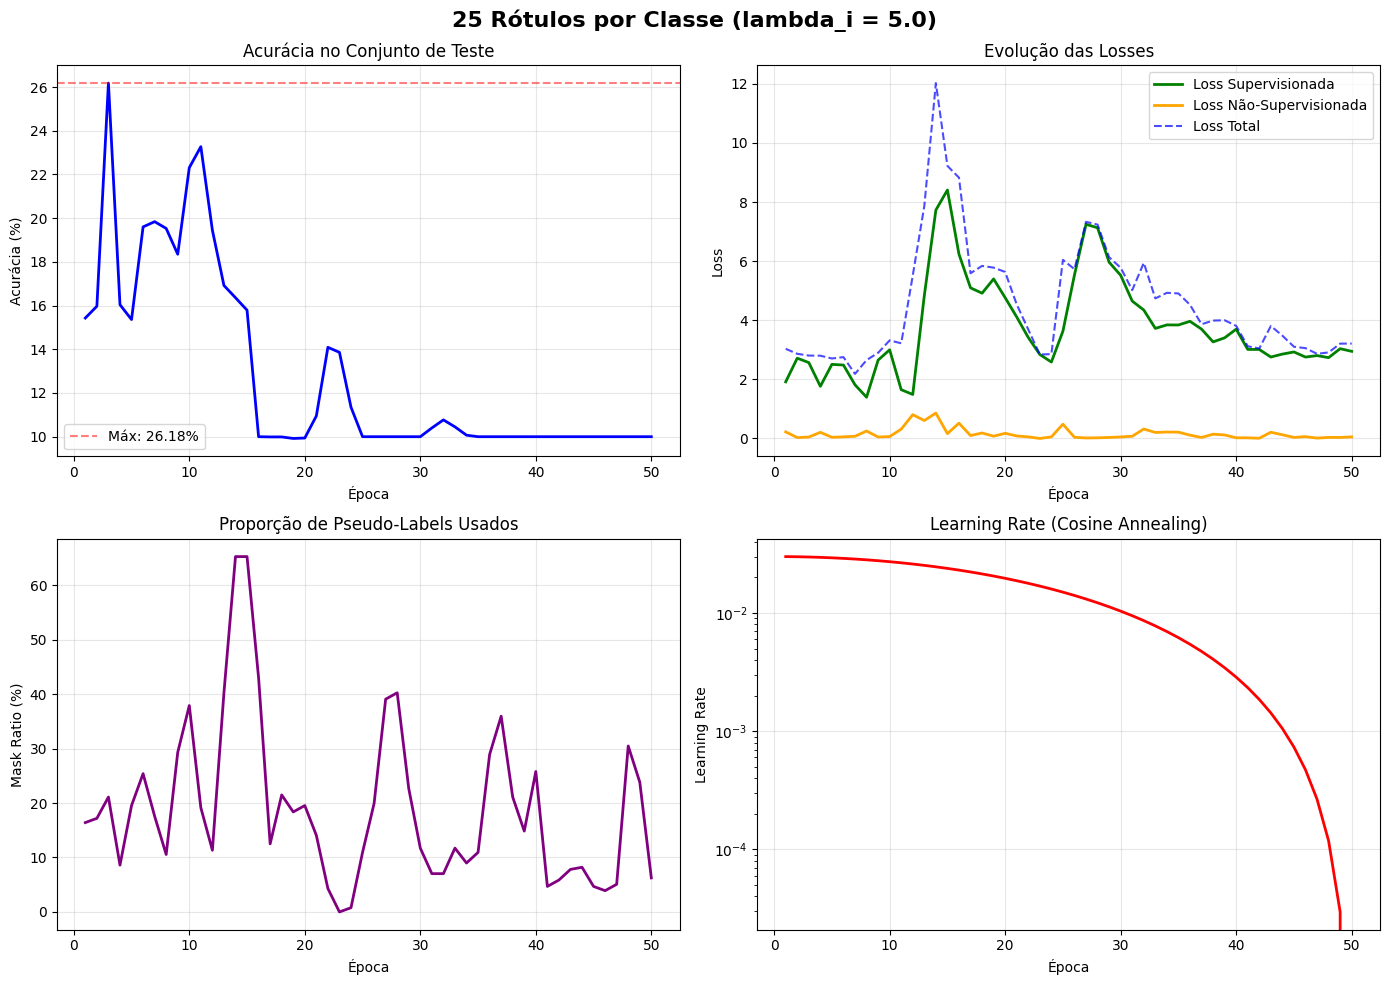

Epoch 1/50: 100%|██████████| 1/1 [00:00<00:00,  1.25it/s, Loss=3.858, Ls=2.712, Lu=0.057, Mask=4.69%]


Epoch 1/50:
  Loss: 3.8585 (Sup: 2.7118, Unsup: 0.0573)
  Mask Ratio: 4.69%
  Test Accuracy: 10.00%
  LR: 0.029970
------------------------------------------------------------


Epoch 2/50: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s, Loss=7.635, Ls=7.085, Lu=0.028, Mask=73.05%]


Epoch 2/50:
  Loss: 7.6348 (Sup: 7.0846, Unsup: 0.0275)
  Mask Ratio: 73.05%
  Test Accuracy: 10.00%
  LR: 0.029882
------------------------------------------------------------


Epoch 3/50: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s, Loss=6.335, Ls=5.804, Lu=0.027, Mask=41.41%]


...

Epoch 48/50:
  Loss: 5.3433 (Sup: 4.7584, Unsup: 0.0292)
  Mask Ratio: 44.14%
  Test Accuracy: 10.00%
  LR: 0.000118
------------------------------------------------------------


Epoch 49/50: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s, Loss=4.812, Ls=4.294, Lu=0.026, Mask=34.77%]


Epoch 49/50:
  Loss: 4.8118 (Sup: 4.2945, Unsup: 0.0259)
  Mask Ratio: 34.77%
  Test Accuracy: 10.00%
  LR: 0.000030
------------------------------------------------------------


Epoch 50/50: 100%|██████████| 1/1 [00:00<00:00,  1.28it/s, Loss=5.366, Ls=4.661, Lu=0.035, Mask=30.47%]


Epoch 50/50:
  Loss: 5.3656 (Sup: 4.6612, Unsup: 0.0352)
  Mask Ratio: 30.47%
  Test Accuracy: 10.00%
  LR: 0.000000
------------------------------------------------------------


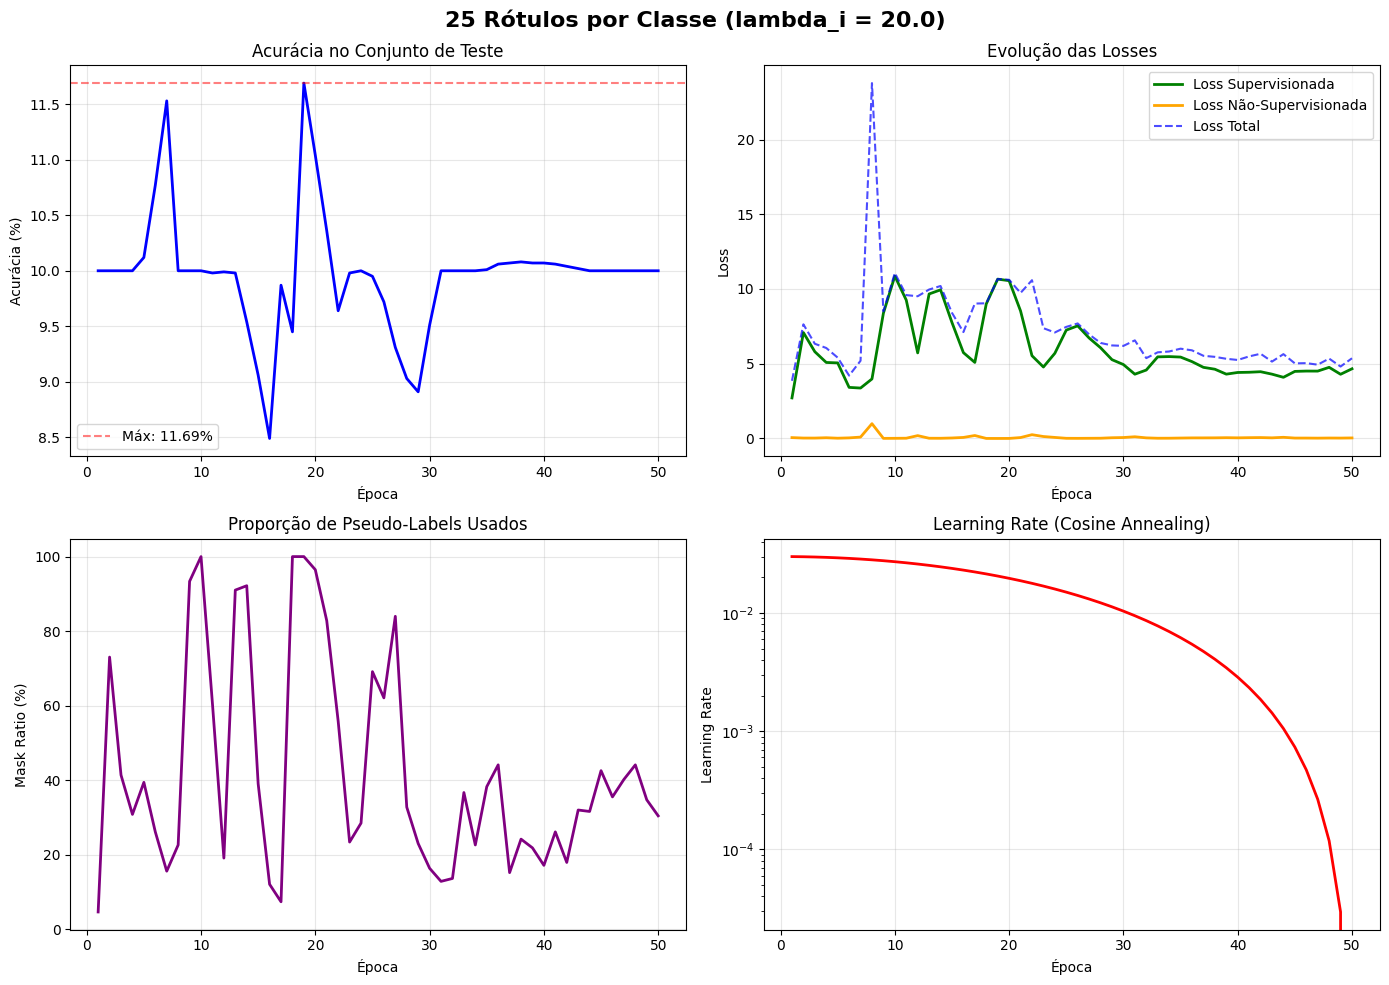

In [17]:
# ===== CONFIGURAÇÕES DO EXPERIMENTO 3 =====
NUM_LABELS_PER_CLASS = 25
BATCH_SIZE = 256
NUM_EPOCHS = 50
LEARNING_RATE = 0.03
LAMBDA_U = 1.0

print("="*60)
print("EXPERIMENTO 3: 25 RÓTULOS POR CLASSE")
print("="*60)
print(f"Configurações:")
print(f"  - Rótulos por classe: {NUM_LABELS_PER_CLASS}")
print(f"  - Total de rótulos: {NUM_LABELS_PER_CLASS * 10}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Épocas: {NUM_EPOCHS}")
print(f"  - Learning rate: {LEARNING_RATE}")
print("="*60)


# ===== CRIAR DATALOADERS =====
labeled_loader_25, unlabeled_loader_25, test_loader_25 = create_dataloaders(
    num_labels_per_class=NUM_LABELS_PER_CLASS,
    batch_size=BATCH_SIZE,
    num_workers=0)

# ===== CRIAR MODELO =====
model_25label = get_resnet18_cifar10(num_classes=10).to(device)

lambdas = [0.5, 1.0, 2.0, 5.0, 20.0]
for lambd in lambdas:
    history_25label = train_fixmatch(
    model=model_25label,
    labeled_loader=labeled_loader_25,
    unlabeled_loader=unlabeled_loader_25,
    test_loader=test_loader_25,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    threshold=0.95,
    lambda_u=lambd,
    device=device
    )
    # Visualizar resultados do Experimento 4
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'25 Rótulos por Classe (lambda_i = {lambd})', fontsize=16, fontweight='bold')
    
    epochs = range(1, len(history_25label['test_accuracy']) + 1)
    
    # 1. Acurácia no Teste
    axes[0, 0].plot(epochs, history_25label['test_accuracy'], 'b-', linewidth=2)
    axes[0, 0].set_xlabel('Época')
    axes[0, 0].set_ylabel('Acurácia (%)')
    axes[0, 0].set_title('Acurácia no Conjunto de Teste')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].axhline(y=max(history_25label['test_accuracy']), color='r', linestyle='--',
                        alpha=0.5, label=f'Máx: {max(history_25label["test_accuracy"]):.2f}%')
    axes[0, 0].legend()
    
    # 2. Losses
    axes[0, 1].plot(epochs, history_25label['train_loss_supervised'], 'g-', linewidth=2, label='Loss Supervisionada')
    axes[0, 1].plot(epochs, history_25label['train_loss_unsupervised'], 'orange', linewidth=2, label='Loss Não-Supervisionada')
    axes[0, 1].plot(epochs, history_25label['train_loss'], 'b--', linewidth=1.5, label='Loss Total', alpha=0.7)
    axes[0, 1].set_xlabel('Época')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].set_title('Evolução das Losses')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Mask Ratio
    axes[1, 0].plot(epochs, [m * 100 for m in history_25label['mask_ratio']], 'purple', linewidth=2)
    axes[1, 0].set_xlabel('Época')
    axes[1, 0].set_ylabel('Mask Ratio (%)')
    axes[1, 0].set_title('Proporção de Pseudo-Labels Usados')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Learning Rate
    axes[1, 1].plot(epochs, history_25label['learning_rate'], 'red', linewidth=2)
    axes[1, 1].set_xlabel('Época')
    axes[1, 1].set_ylabel('Learning Rate')
    axes[1, 1].set_title('Learning Rate (Cosine Annealing)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_yscale('log')
    
    plt.tight_layout()
    plt.show()